# Seoul Bike Data Final Report
Amelia Jiang-Yu: ajiangy1@jhu.edu  
Raj Gosain: rgosain3@jhu.edu

## 0 Introduction

### a. Data Set

Link: https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand

The Seoul Bike Sharing Demand dataset details the number of public bicycles rented each hour via the Seoul Bike Sharing System. The dataset includes weather information such Temperature, Humidity, Windspeed, Visibility, Dewpoint, Solar radiation, Snowfall, and Rainfall. Other information includes the season, whether the day is a holiday or not, and whether the hour is functional or not.

The response variable is **rented bike count** at each hour. Explanatory variables include:
- **Date**: categorical
- **Hour**: categorical
- **Temperature** (in Celsius): continuous
- **Humidity** (%): continuous
- **Wind Speed** (m/s): continuous
- **Visibility** (10 m): integer-valued
- **Dew Point Temperature** (in Celsius): continuous
- **Solar Radiation** (MJ/m2): continuous
- **Rainfall** (mm): continuous
- **Snowfall** (cm): continuous
- **Seasons**: categorical (winter, spring, summer, fall)
- **Holiday**: binary (holiday, no holiday)
- **Functioning Day**: binary (yes, no)

In [5]:
import pandas as pd
df = pd.read_csv("SeoulBikeData.csv", encoding="latin-1")
print(df.shape)
df.head()

(8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### b. Data Visualization

In [18]:
continuous_cols = df.select_dtypes(include=['number']).columns.tolist()
continuous_cols.remove('Hour')
categorical_cols = ['Date', 'Hour', 'Seasons']
binary_cols = ['Holiday', 'Functioning Day']

print("Categorical:", categorical_cols)
print("Continuous:", continuous_cols)
print("Binary:", binary_cols)

Categorical: ['Date', 'Hour', 'Seasons']
Continuous: ['Rented Bike Count', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']
Binary: ['Holiday', 'Functioning Day']


#### Categorical Variables

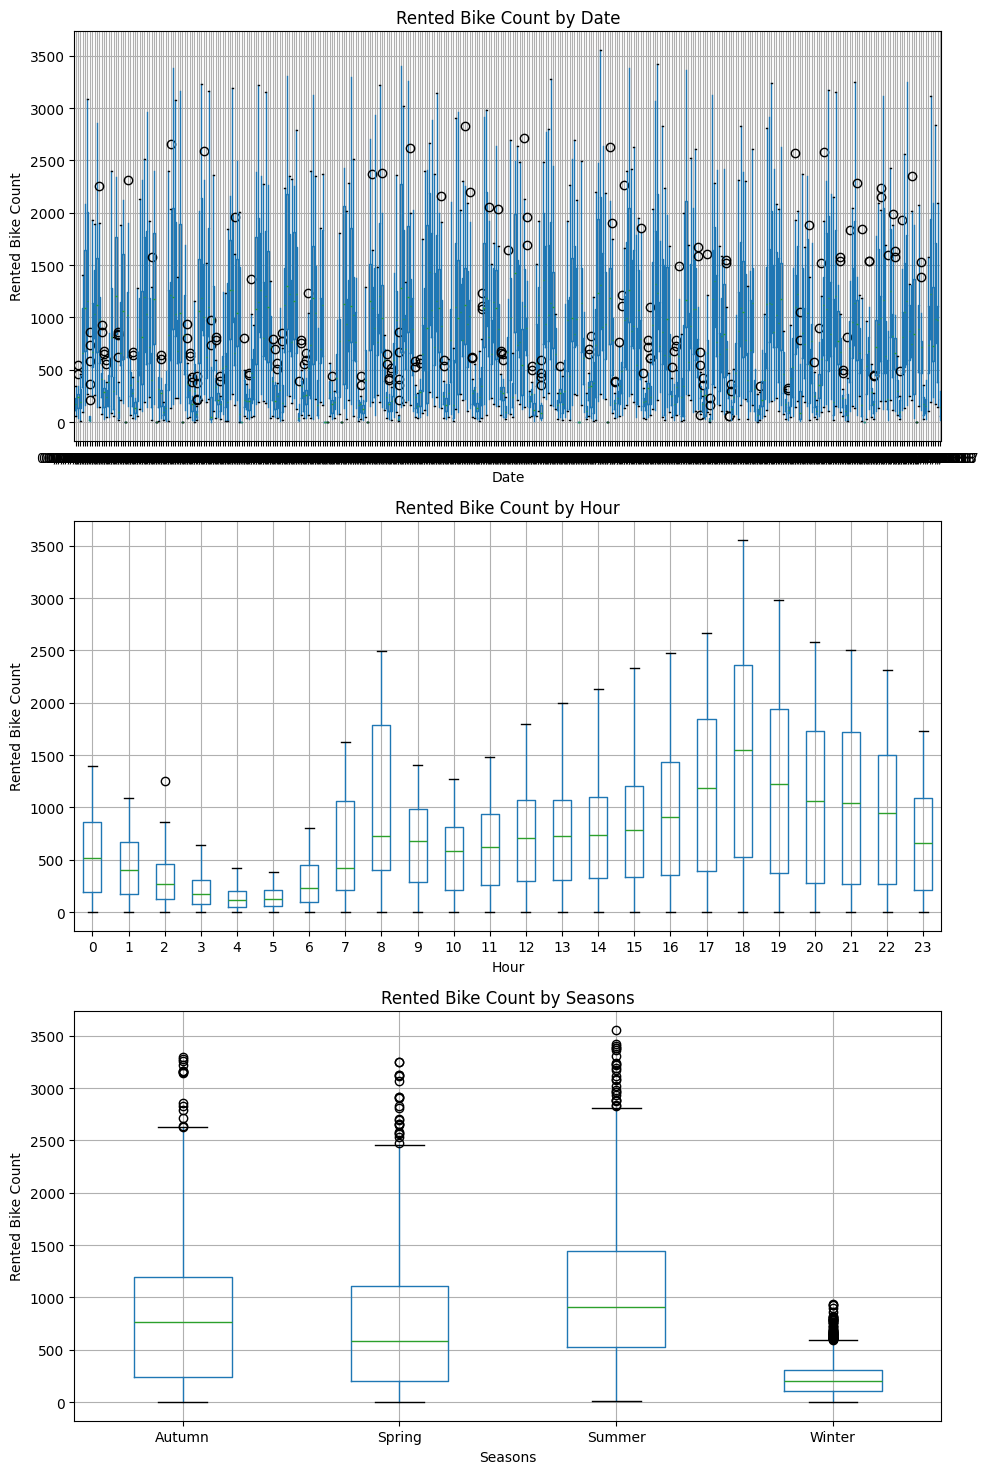

In [31]:
import matplotlib.pyplot as plt

Y = 'Rented Bike Count'


fig, axs = plt.subplots(3, 1, figsize=(10, 15))
axs = axs.flatten()

i = 0
for col in categorical_cols:
    if col != Y:
        df.boxplot(column=Y, by=col, ax=axs[i])

        axs[i].set_title(f'{Y} by {col}')
        axs[i].set_xlabel(col)
        axs[i].set_ylabel(Y)

        i += 1

# Remove the automatic "Boxplot grouped by ..." super-title
plt.suptitle("")

plt.tight_layout()
plt.show()


#### Continuous Variables

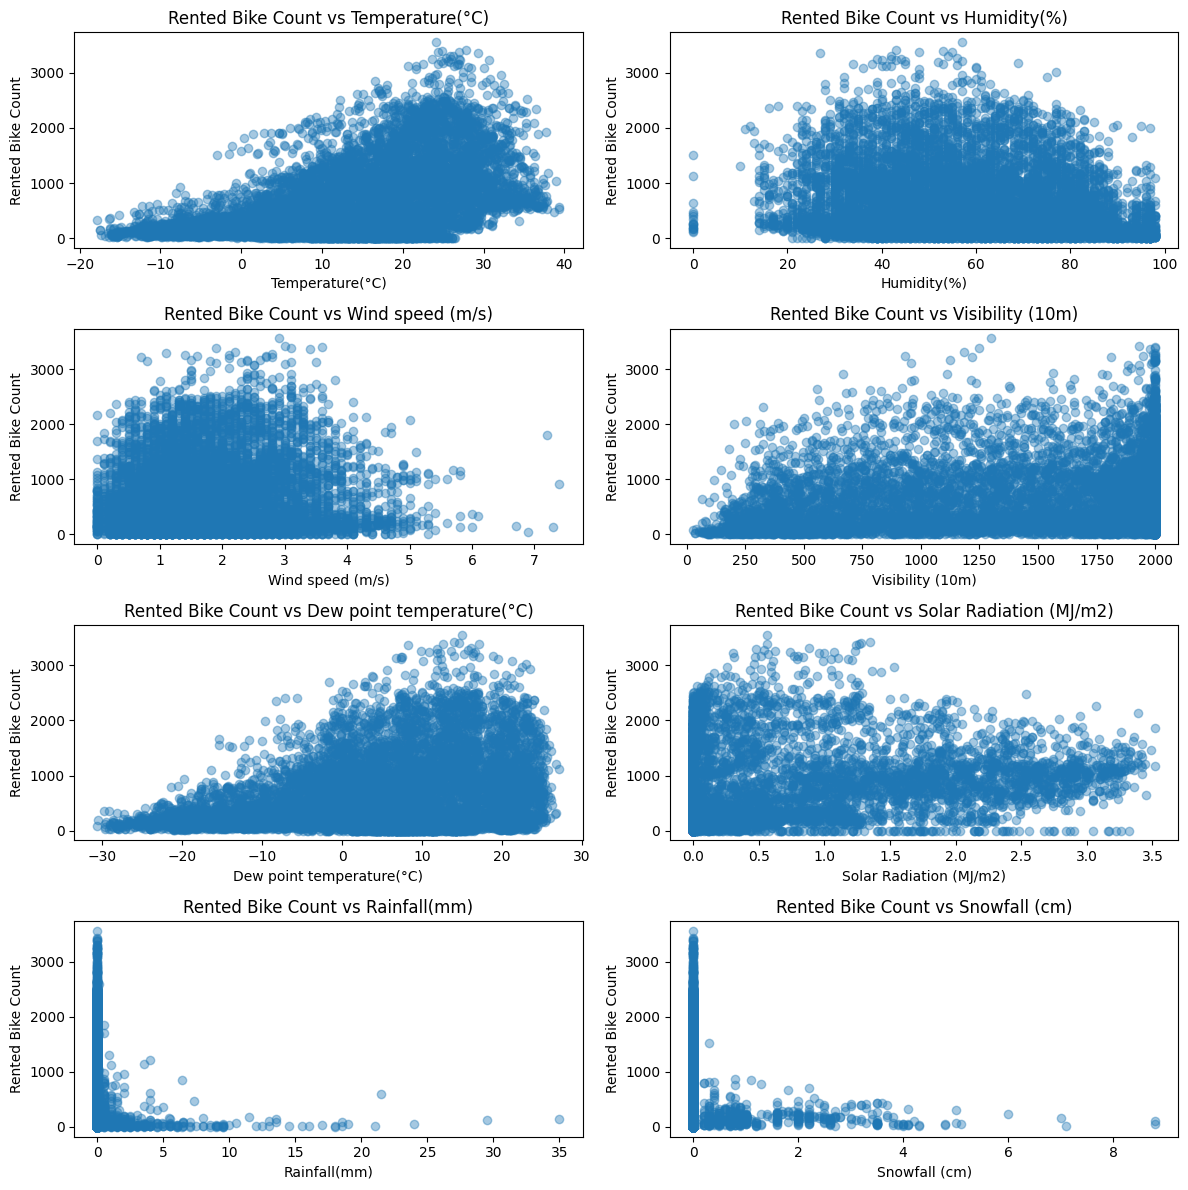

In [32]:
fig, axs = plt.subplots(4, 2, figsize=(12, 12))
axs = axs.flatten()   # flatten to make indexing easier

i = 0
for col in continuous_cols:
    if col != Y:
        ax = axs[i]
        ax.scatter(df[col], df[Y], alpha=0.4)
        ax.set_xlabel(col)
        ax.set_ylabel(Y)
        ax.set_title(f'{Y} vs {col}')
        i += 1

plt.tight_layout()
plt.show()


#### Binary Variables

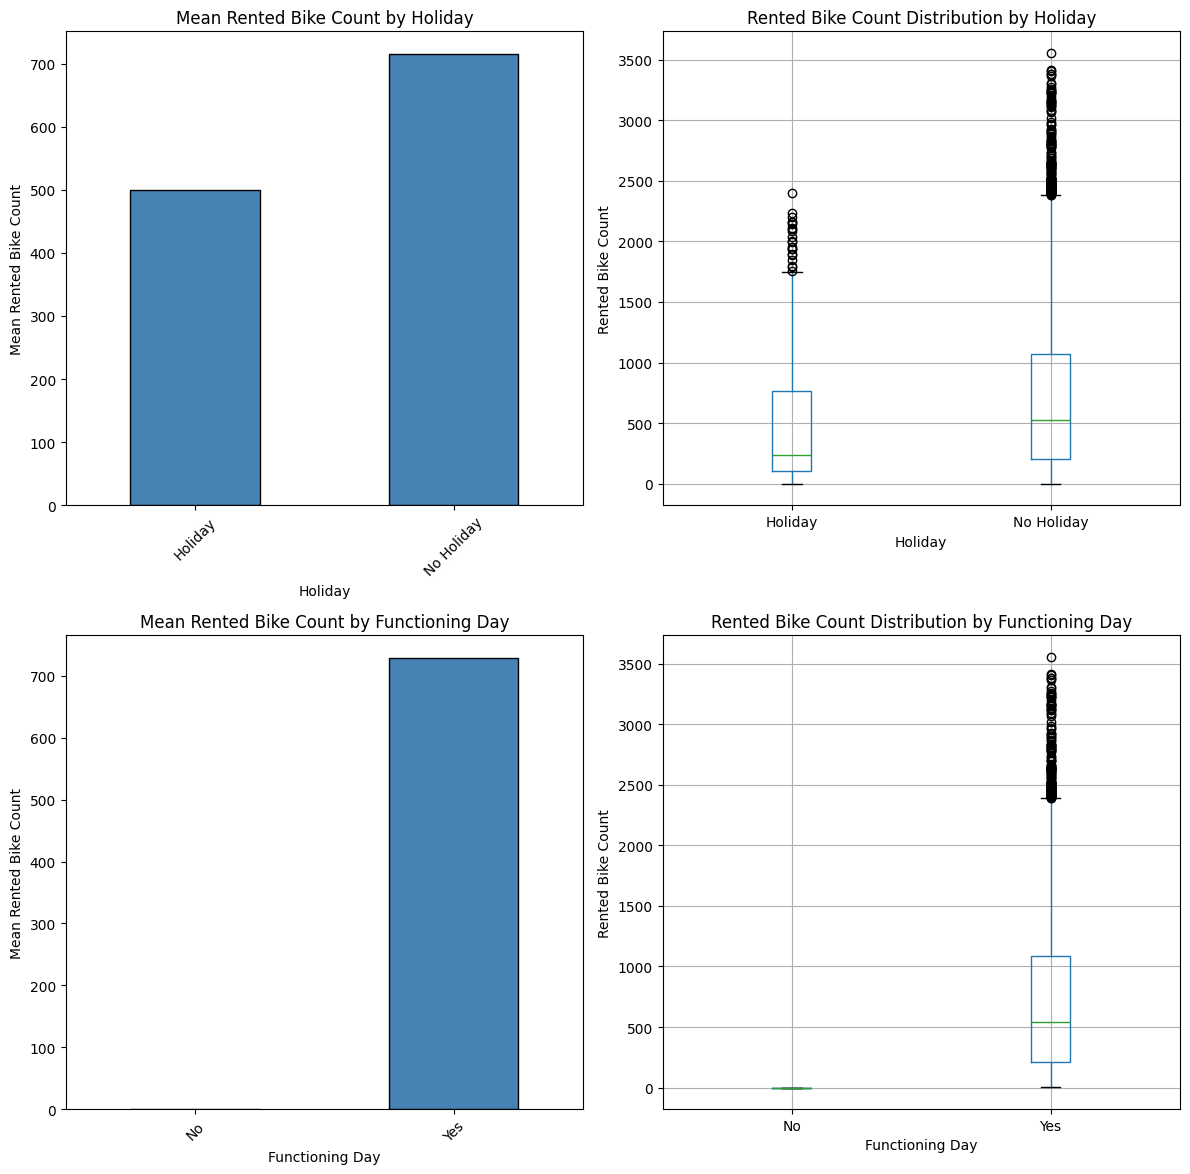

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs = axs.flatten()

i = 0
for col in binary_cols:
    if col != Y:

        # --- Proportion bar plot ---
        prop = df.groupby(col)[Y].mean()
        ax = axs[i]

        prop.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
        ax.set_title(f'Mean {Y} by {col}')
        ax.set_ylabel(f'Mean {Y}')
        ax.set_xlabel(col)
        ax.set_xticks(range(len(prop.index)))
        ax.set_xticklabels(prop.index.astype(str), rotation=45)

        i += 1

        # --- Boxplot ---
        ax = axs[i]
        df.boxplot(column=Y, by=col, ax=ax)

        ax.set_title(f'{Y} Distribution by {col}')
        ax.set_xlabel(col)
        ax.set_ylabel(Y)

        # Remove the automatic "Boxplot grouped by col" super-title
        plt.suptitle("")

        i += 1

plt.tight_layout()
plt.show()



### c. Descriptive Statistics

## 1 Best Normal Linear Model

### a. Fitting the Model

### b. Model Interpretation

### c. Model Diagnostics

### d. Model Strengths and Limitations

## 2 Simplest Linear Model

### a. Fitting the Model

### b. Model Interpretation

### c. Model Strengths and Limitations

## 3 Generalized Linear Models (GLMs)

### a. Fitting the Model

### b. Comparison to Previous Models

### c. Model Interpretation

### d. Model Diagnostics